In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [160]:
data = pd.read_excel('../Data/Data_finance_lab3.xlsx', sheet_name='data_final')

In [161]:
data.head()

,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,...,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,MARITAL_STATUS,EDUCATION,City,ADDRESS_CURRENT_CITY,PROVINCE_CURRENT
0,16499318,2017-10-10,2018-10-26,12,FC UP DSA TS SCORE 2 NEW- 762,18000000,990000,18990000,45.0,24,...,9000000,0,9600000,20000000,5000000,Other,High School,Tỉnh Yên Bái,Yên Bình,Tỉnh Yên Bái
1,16490594,2017-10-10,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,10000000,550000,10550000,44.5,12,...,5500000,0,7200000,15000000,4000000,Married,High School,Tỉnh Quảng Ninh,Đông Triều,Tỉnh Quảng Ninh
2,16910227,2017-10-28,2018-10-26,11,FC UP CAT B NEW- 610,25000000,1375000,26375000,47.0,24,...,5182000,0,12000000,5200000,1000000,Single,Middle School,Tỉnh Bình Dương,Tân Uyên,Tỉnh Bình Dương
3,16355347,2017-10-04,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,30000000,1650000,31650000,44.5,24,...,10000000,0,18000000,20000000,6000000,Married,Middle School,Tỉnh An Giang,Phú Tân,Tỉnh An Giang
4,16705974,2017-10-18,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,20000000,1100000,21100000,44.5,18,...,7000000,0,12000000,20000000,7000000,Single,High School,Thành phố Hải Phòng,Vĩnh Bảo,Thành phố Hải Phòng


In [162]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   APP_ID                    5000 non-null   int64         
 1   DISBURSALDATE             5000 non-null   datetime64[ns]
 2   REPORT_DATE               5000 non-null   datetime64[ns]
 3   TERM_TMP                  5000 non-null   int64         
 4   PRODUCT_NAME              5000 non-null   object        
 5   LOANAMOUNT_NOT_INSURANCE  5000 non-null   int64         
 6   INSURANCE_FEE             5000 non-null   int64         
 7   LA                        5000 non-null   int64         
 8   EFF_RATE                  5000 non-null   float64       
 9   TERM                      5000 non-null   int64         
 10  COUNT_TERM_RECEIPT        4909 non-null   float64       
 11  flag term                 4909 non-null   float64       
 12  SUM_RECEIPT_AMT     

In [163]:
missing_values = data.isnull().sum()
missing_values

APP_ID                         0
DISBURSALDATE                  0
REPORT_DATE                    0
TERM_TMP                       0
PRODUCT_NAME                   0
LOANAMOUNT_NOT_INSURANCE       0
INSURANCE_FEE                  0
LA                             0
EFF_RATE                       0
TERM                           0
COUNT_TERM_RECEIPT            91
flag term                     91
SUM_RECEIPT_AMT               91
Unnamed: 13                 4849
flag loan amt                 91
flag final                    91
RESULT_YES/NO                  0
EMI                            0
GENDER                         0
AGE                            0
Number of Children          4200
PERSONAL_INCOME                0
ADDITIONAL_INCOME              0
PERSONAL_EXPENSE               0
FAMILY_INCOME                  0
FAMILY_EXPENSE                 0
MARITAL_STATUS                 0
EDUCATION                      0
City                           0
ADDRESS_CURRENT_CITY           0
PROVINCE_C

In [164]:
data['COUNT_TERM_RECEIPT'] = data['COUNT_TERM_RECEIPT'].fillna(data['COUNT_TERM_RECEIPT'].mean())
data['SUM_RECEIPT_AMT'] = data['SUM_RECEIPT_AMT'].fillna(data['SUM_RECEIPT_AMT'].mean())
data['Number of Children'] = data['Number of Children'].fillna(0)

data['RESULT_YES/NO'] = data['RESULT_YES/NO'].astype('object')
data['INCOME'] = data['PERSONAL_INCOME'] + data['ADDITIONAL_INCOME'] + data['FAMILY_INCOME'] - data['FAMILY_EXPENSE'] - data['PERSONAL_EXPENSE']

data.isnull().sum()


APP_ID                         0
DISBURSALDATE                  0
REPORT_DATE                    0
TERM_TMP                       0
PRODUCT_NAME                   0
LOANAMOUNT_NOT_INSURANCE       0
INSURANCE_FEE                  0
LA                             0
EFF_RATE                       0
TERM                           0
COUNT_TERM_RECEIPT             0
flag term                     91
SUM_RECEIPT_AMT                0
Unnamed: 13                 4849
flag loan amt                 91
flag final                    91
RESULT_YES/NO                  0
EMI                            0
GENDER                         0
AGE                            0
Number of Children             0
PERSONAL_INCOME                0
ADDITIONAL_INCOME              0
PERSONAL_EXPENSE               0
FAMILY_INCOME                  0
FAMILY_EXPENSE                 0
MARITAL_STATUS                 0
EDUCATION                      0
City                           0
ADDRESS_CURRENT_CITY           0
PROVINCE_C

In [165]:
datetime_vars = data.select_dtypes(include='datetime').columns
datetime_vars

Index(['DISBURSALDATE', 'REPORT_DATE'], dtype='object')

In [166]:
result_counts = data.groupby(['DISBURSALDATE', 'RESULT_YES/NO']).size().reset_index(name='counts')
result_counts

pivot_table = result_counts.pivot(index='DISBURSALDATE', columns='RESULT_YES/NO', values='counts').fillna(0)

pivot_table.columns = ['Label_0', 'Label_1']

print(pivot_table)


               Label_0  Label_1
DISBURSALDATE                  
2017-10-01          13        4
2017-10-02          16       95
2017-10-03          54      160
2017-10-04          40      133
2017-10-05          44      127
2017-10-06          37      121
2017-10-07          20       59
2017-10-08           7       10
2017-10-09          19      125
2017-10-10          52      210
2017-10-11          47      166
2017-10-12          31      186
2017-10-13          42      158
2017-10-14          22       95
2017-10-15           8       19
2017-10-16          17      138
2017-10-17          56      205
2017-10-18          33      204
2017-10-19          53      157
2017-10-20          65      125
2017-10-21          45      108
2017-10-22          28       29
2017-10-23          30      144
2017-10-24          61      157
2017-10-25          77      139
2017-10-26          78      101
2017-10-27         103       83
2017-10-28          81       54
2017-10-29          39       32
2017-10-

In [167]:
categorical_vars = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_vars

['PRODUCT_NAME',
 'RESULT_YES/NO',
 'GENDER',
 'MARITAL_STATUS',
 'EDUCATION',
 'City',
 'ADDRESS_CURRENT_CITY',
 'PROVINCE_CURRENT']

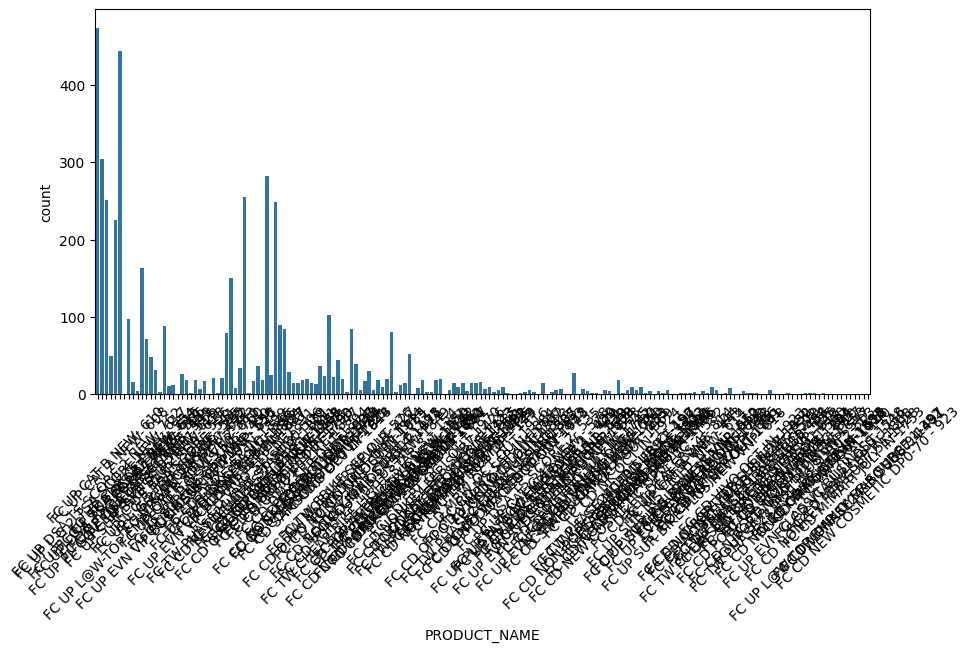

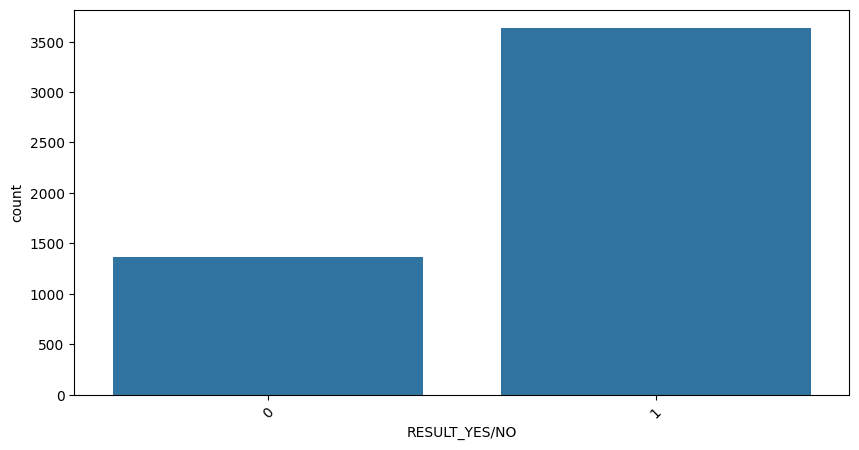

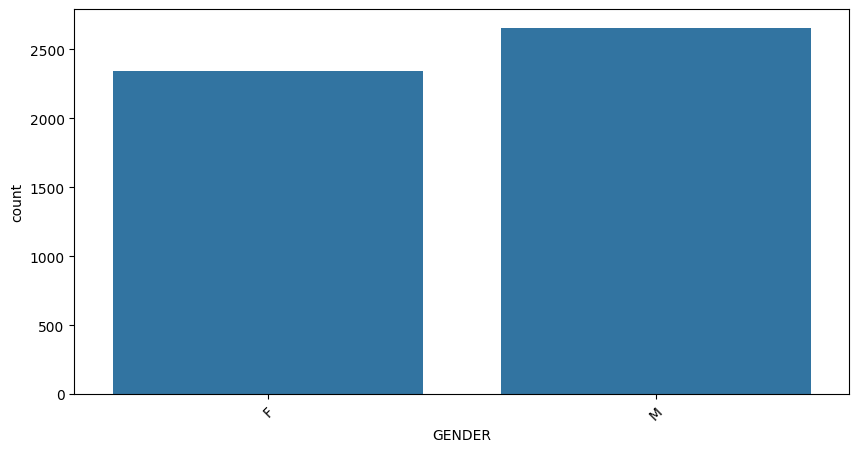

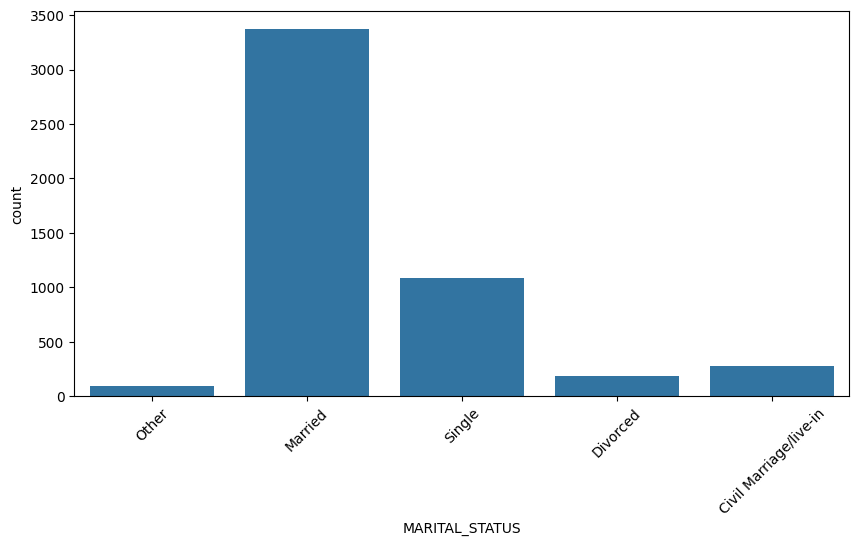

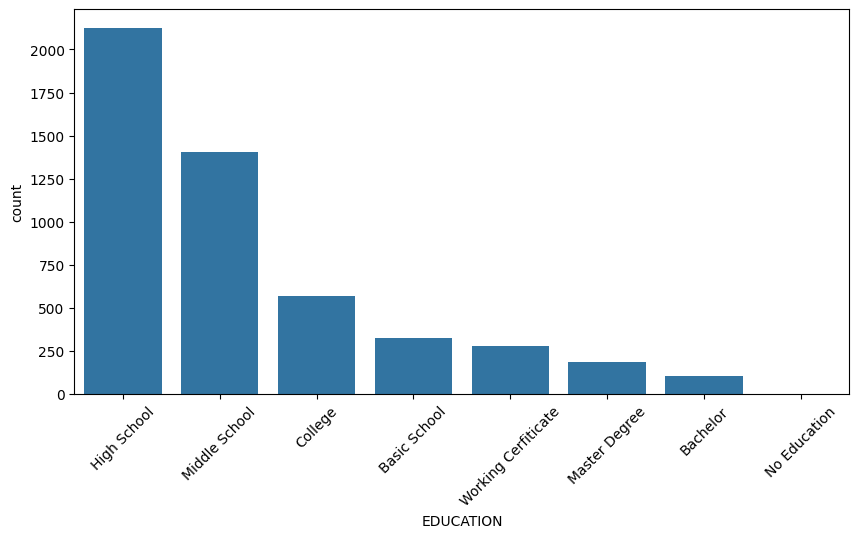

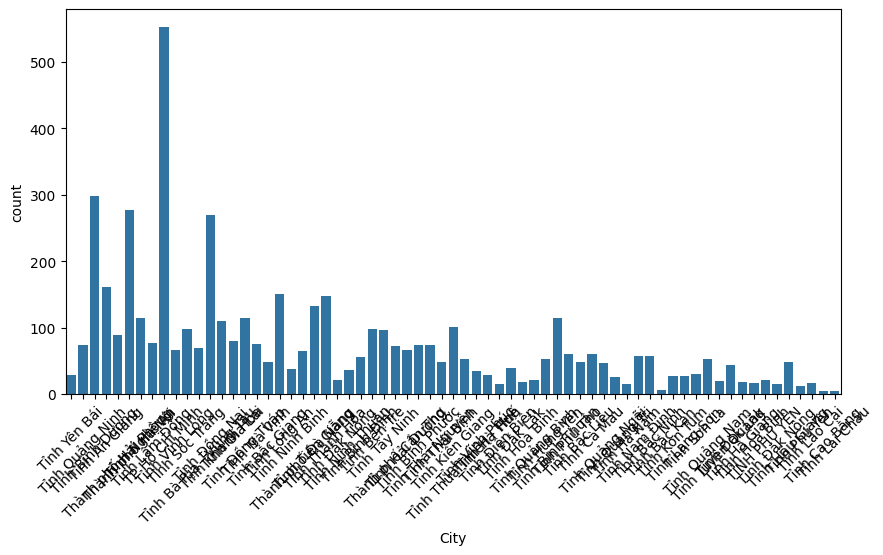

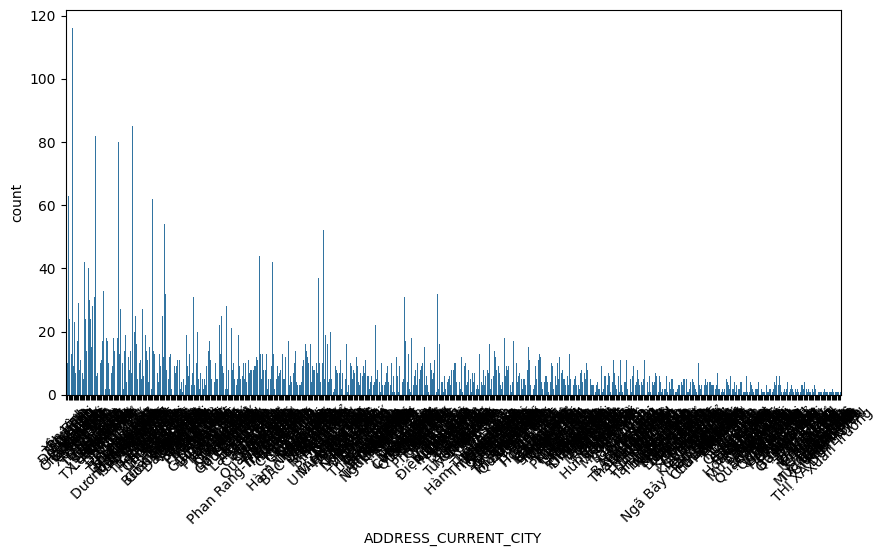

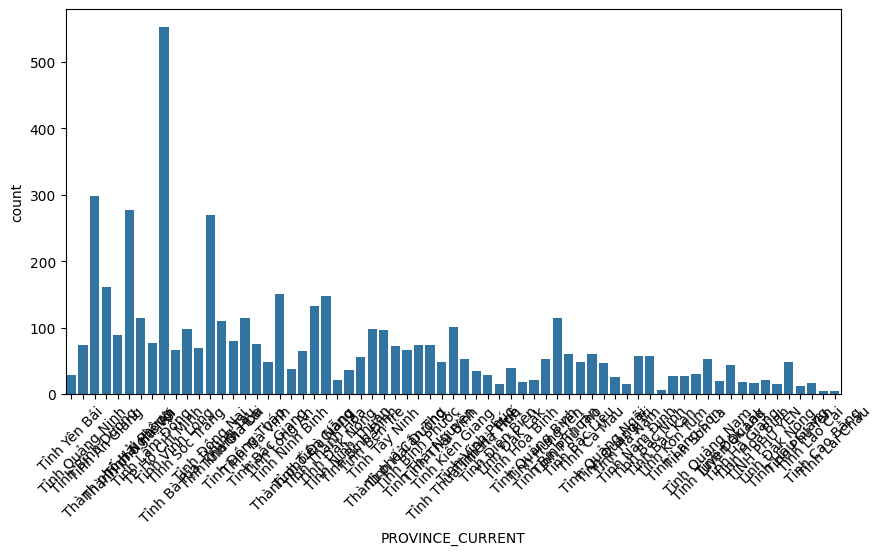

In [168]:
for var in categorical_vars:
    plt.figure(figsize=(10,5))
    sns.countplot(x=var, data=data)
    plt.xticks(rotation=45)
    plt.show()


In [169]:
numerical_vars = data.select_dtypes(include=[np.number]).columns.to_list()
numerical_vars

['APP_ID',
 'TERM_TMP',
 'LOANAMOUNT_NOT_INSURANCE',
 'INSURANCE_FEE',
 'LA',
 'EFF_RATE',
 'TERM',
 'COUNT_TERM_RECEIPT',
 'flag term',
 'SUM_RECEIPT_AMT',
 'Unnamed: 13',
 'flag loan amt',
 'flag final',
 'EMI',
 'AGE',
 'Number of Children',
 'PERSONAL_INCOME',
 'ADDITIONAL_INCOME',
 'PERSONAL_EXPENSE',
 'FAMILY_INCOME',
 'FAMILY_EXPENSE',
 'INCOME']

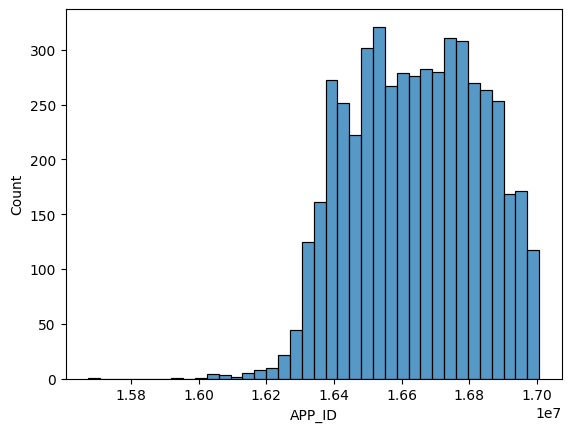

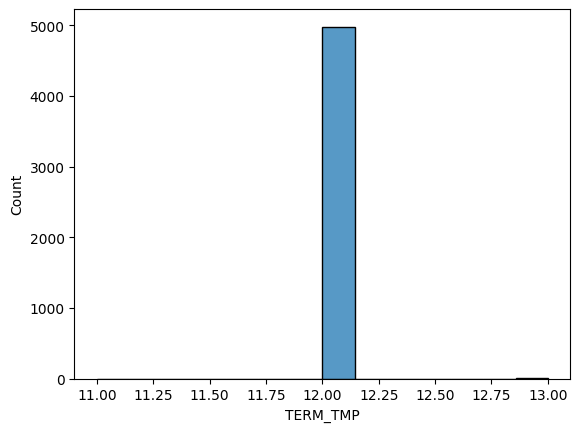

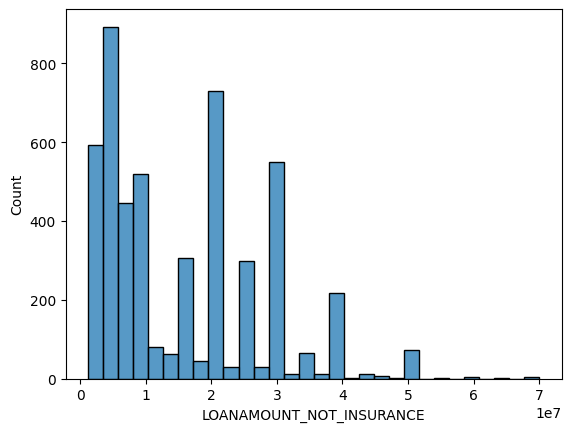

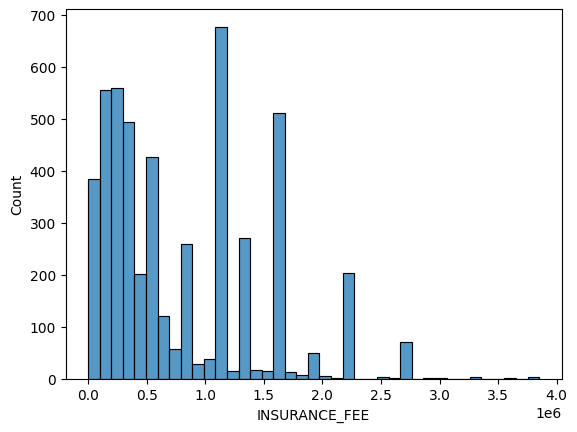

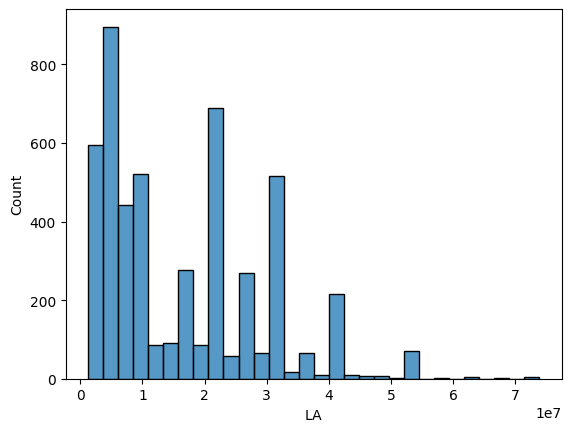

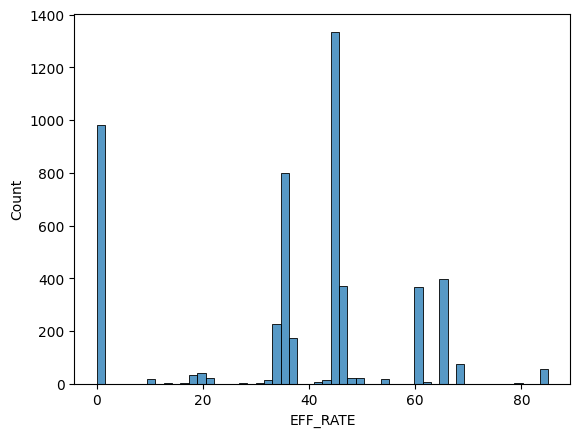

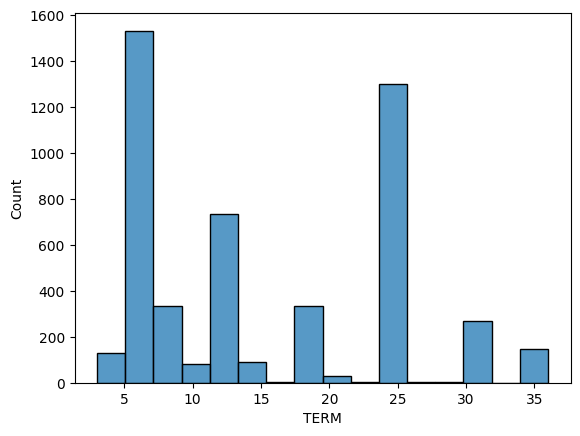

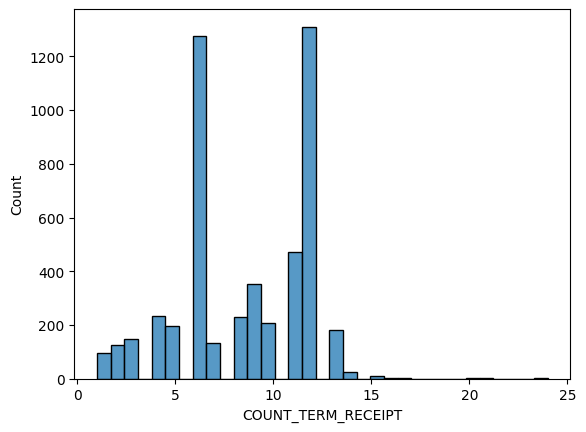

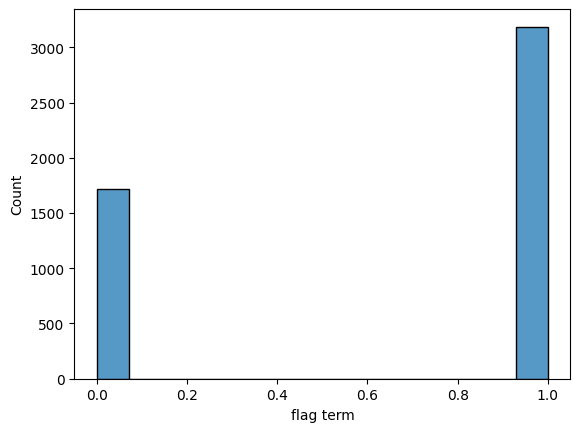

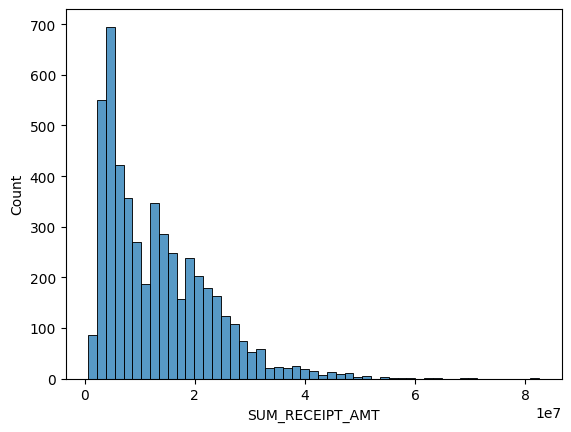

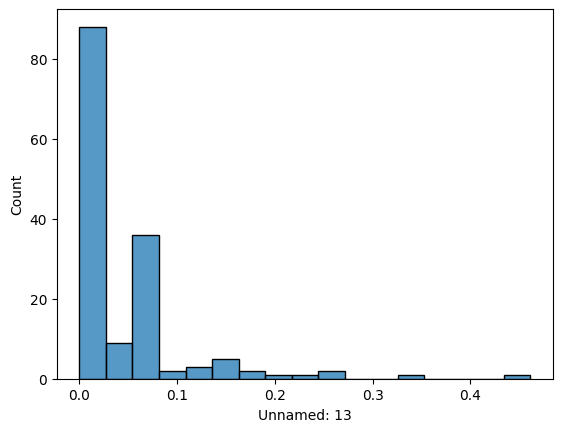

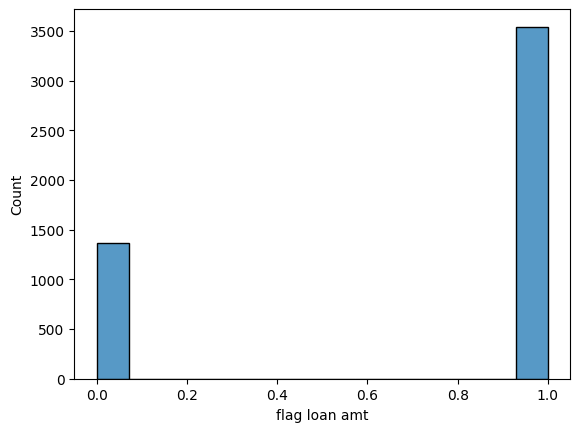

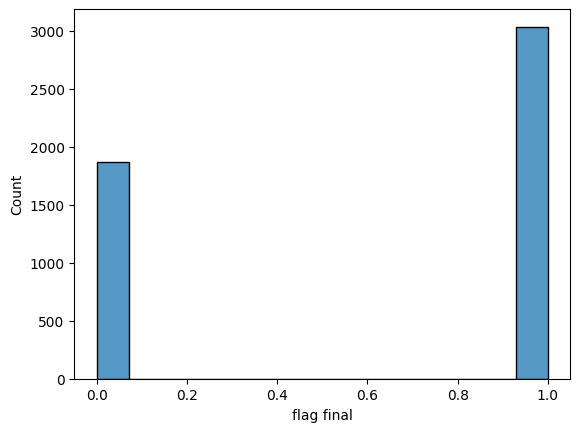

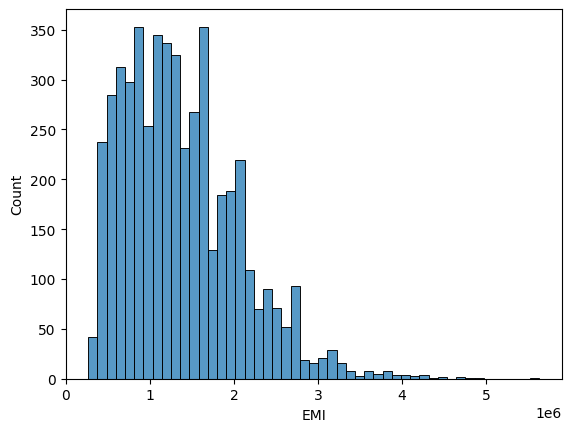

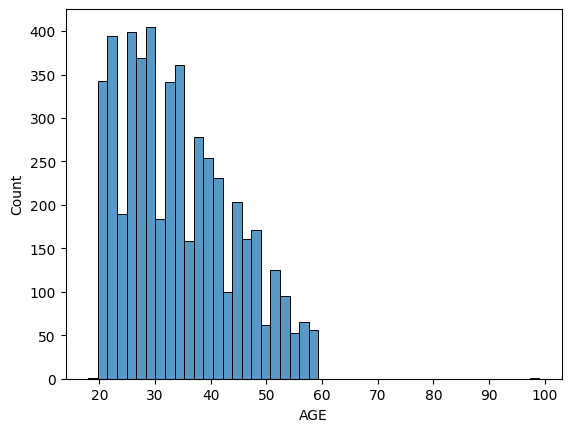

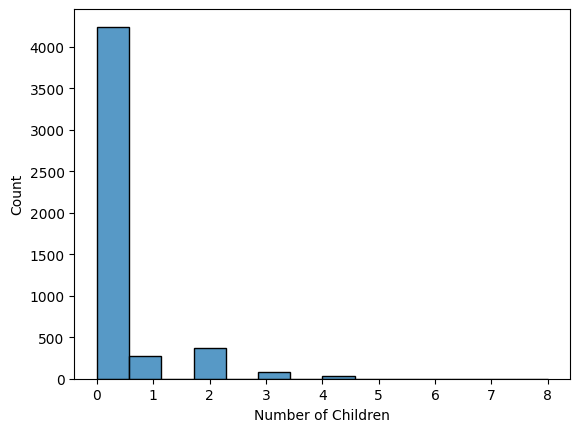

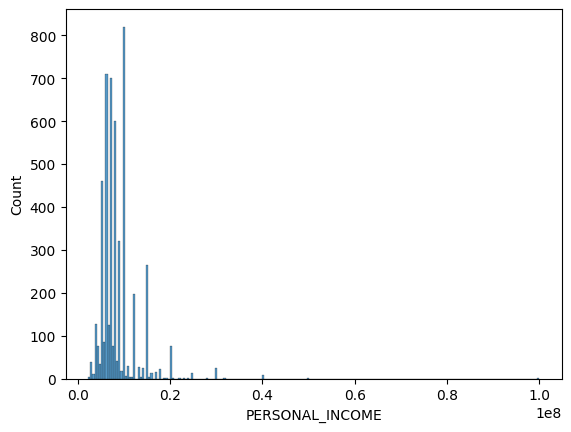

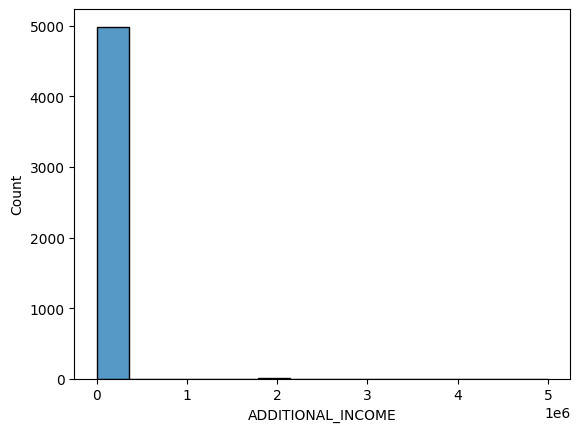

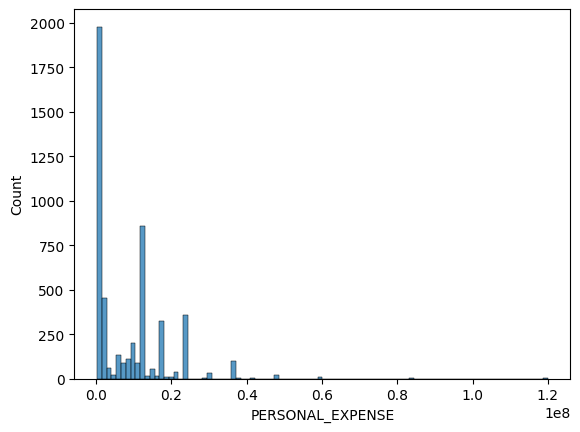

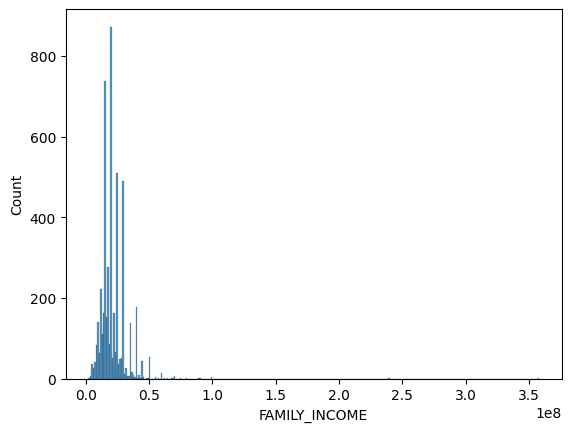

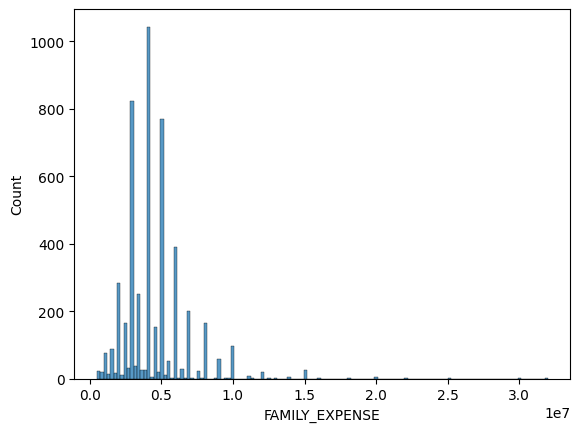

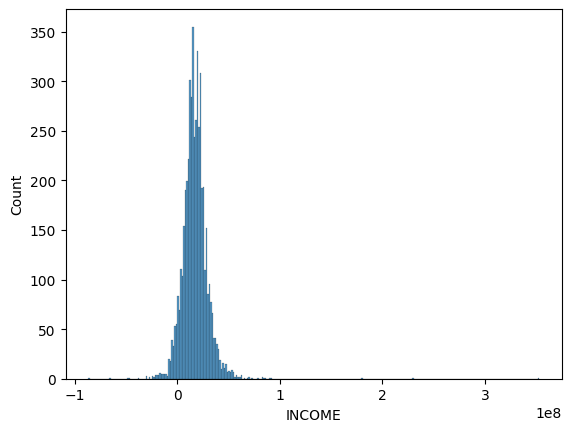

In [170]:
for var in numerical_vars:
    sns.histplot(x=data[var])
    plt.show()


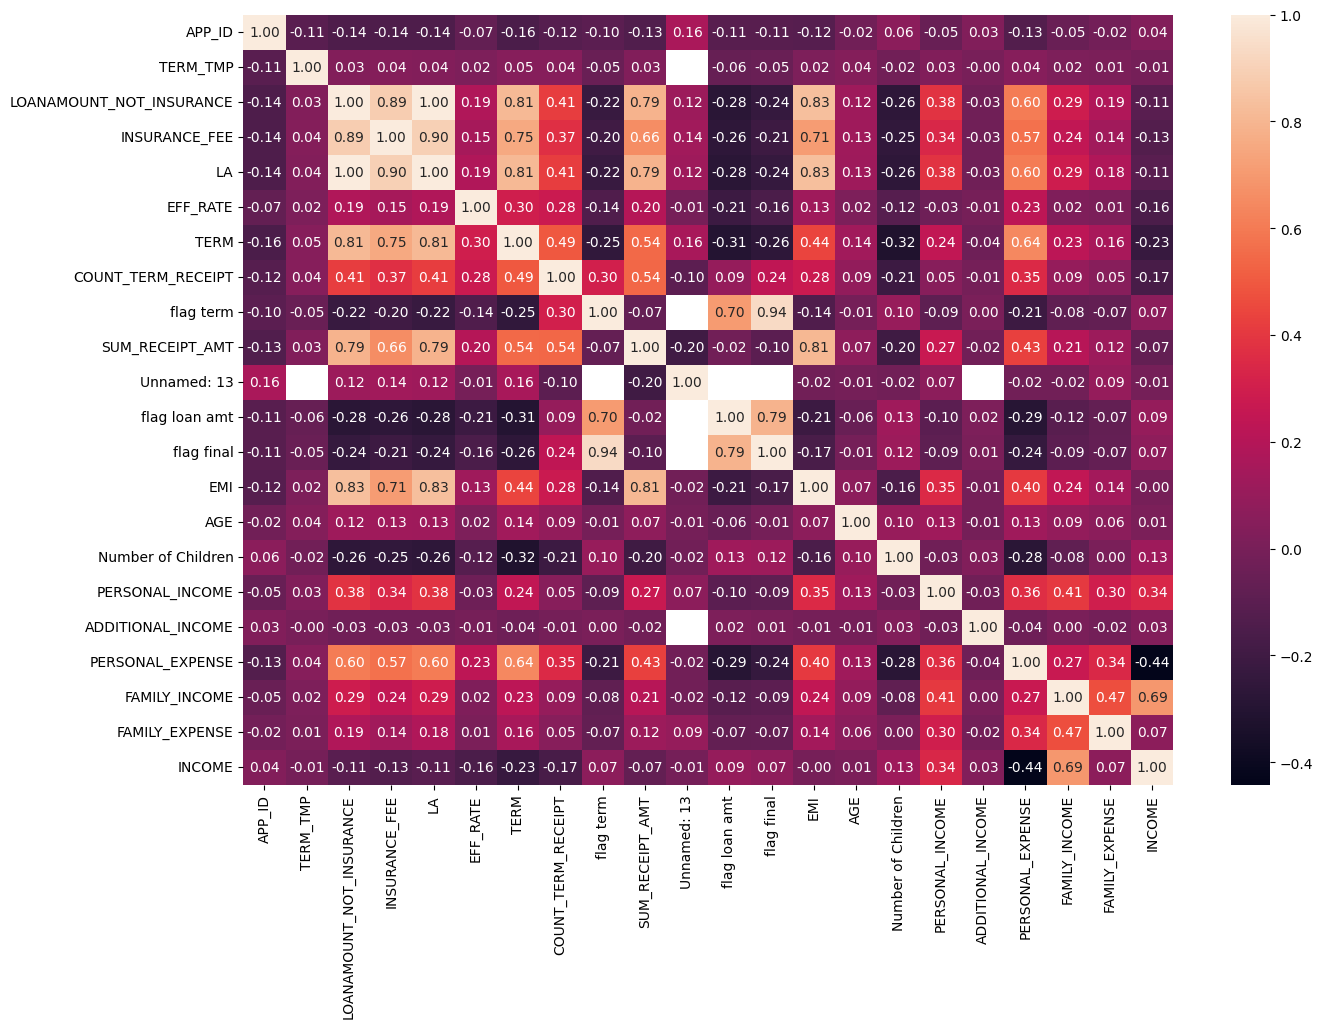

In [171]:
corr_matrix = data[numerical_vars].corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()

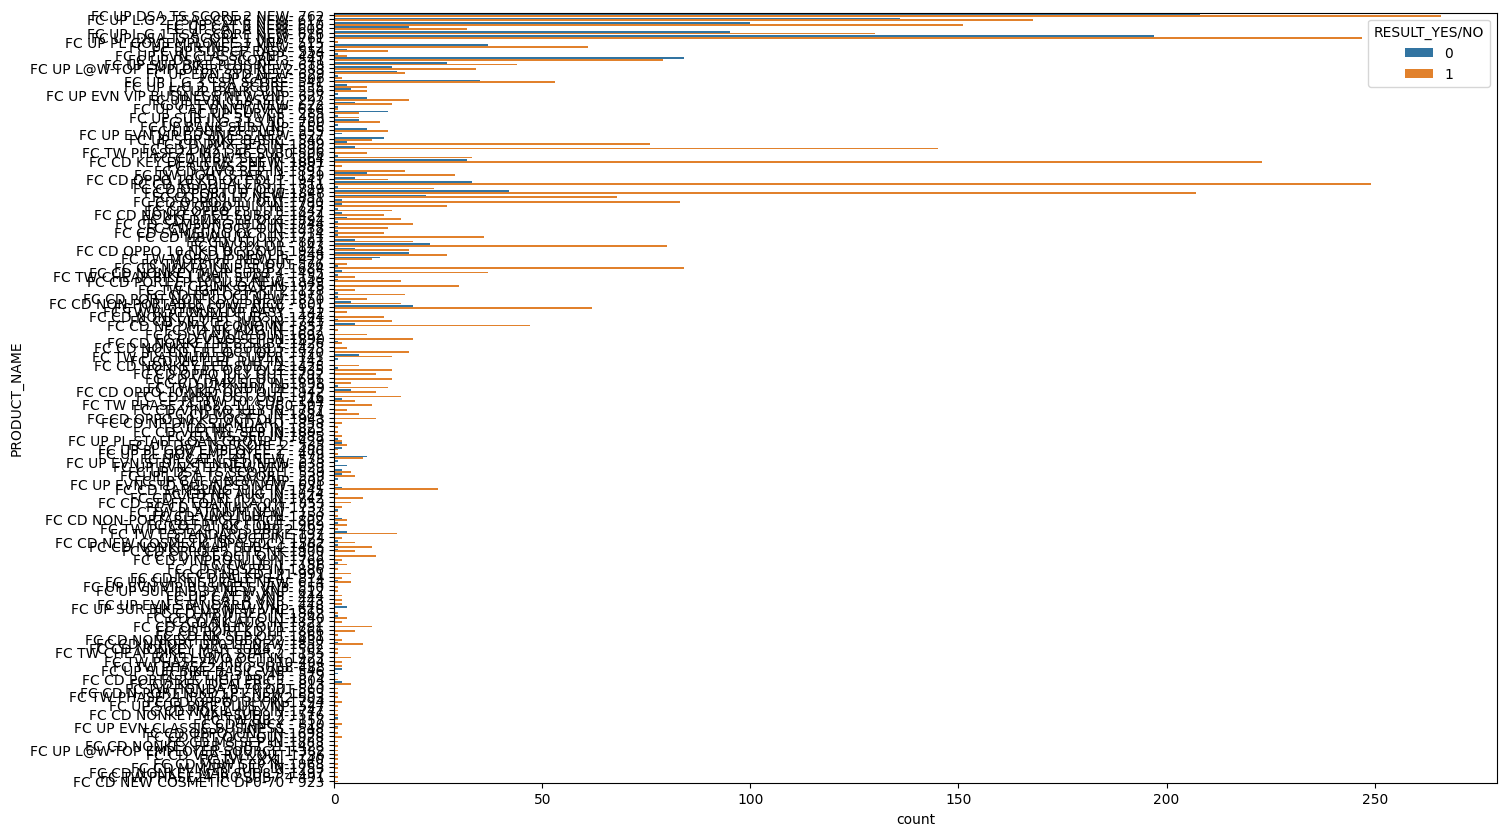

<Figure size 1500x1000 with 0 Axes>

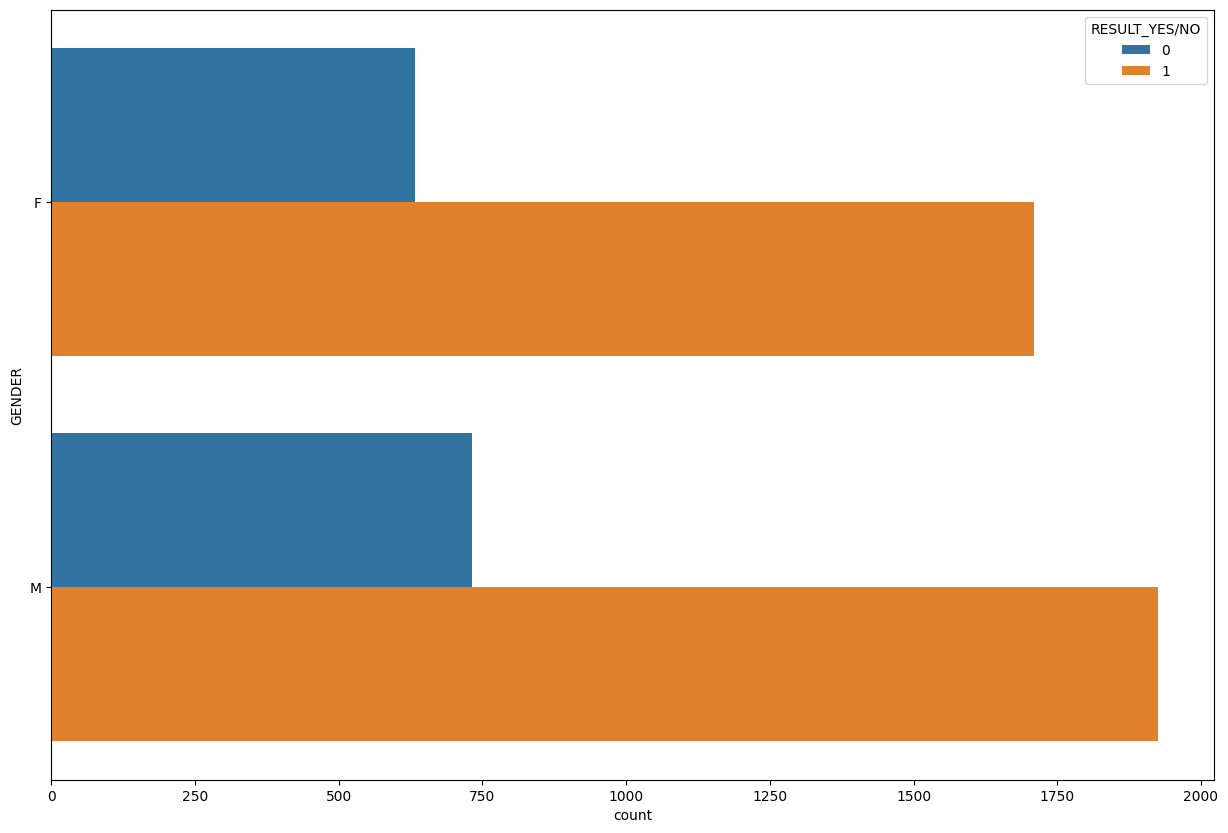

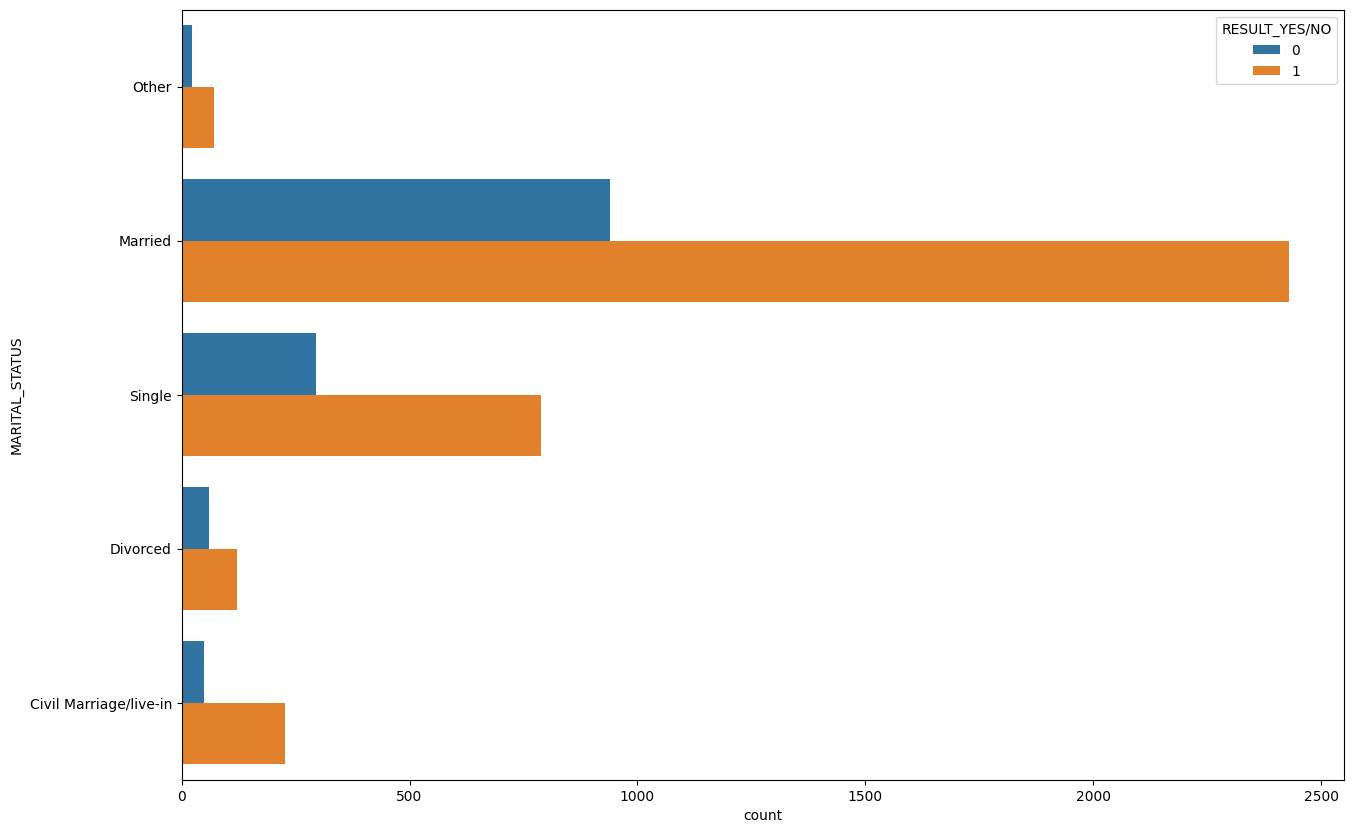

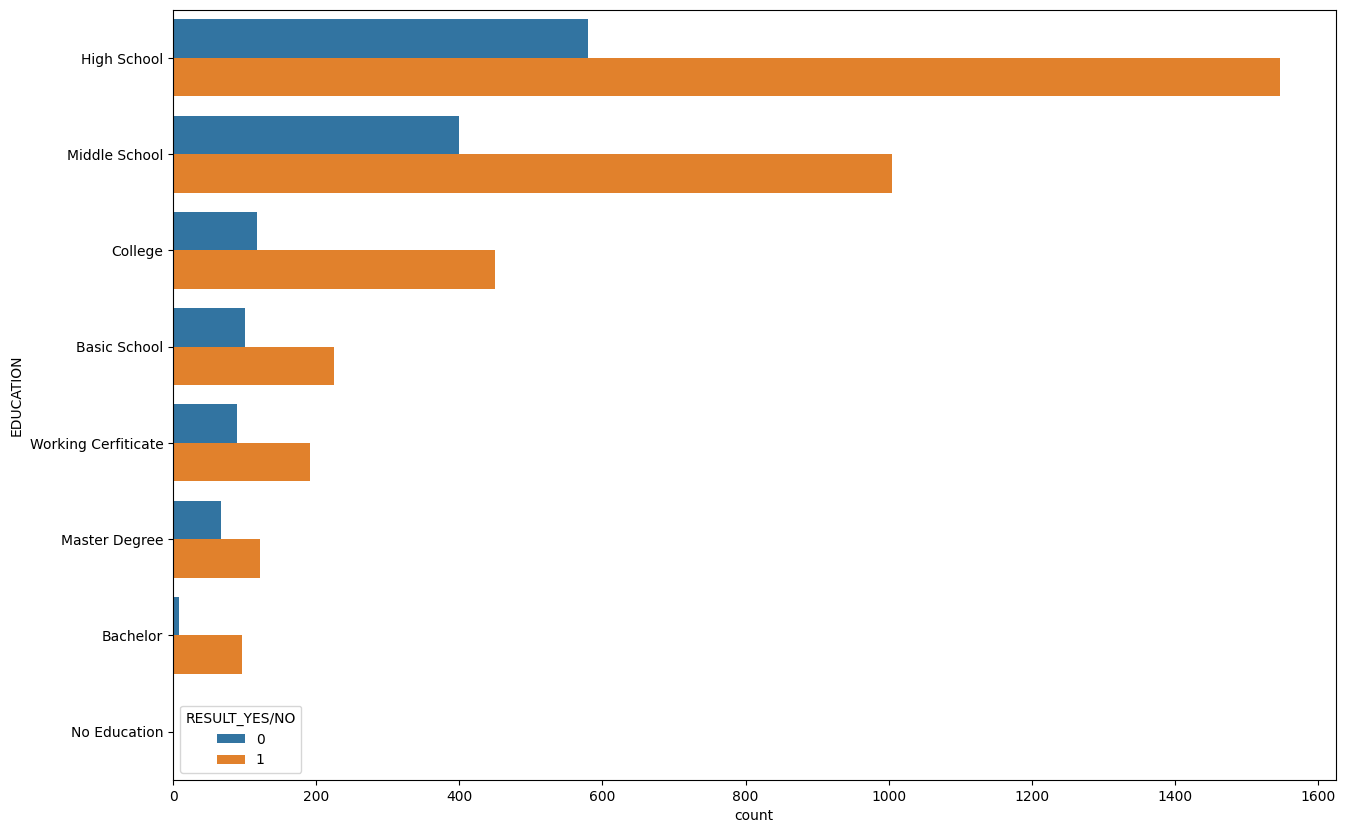

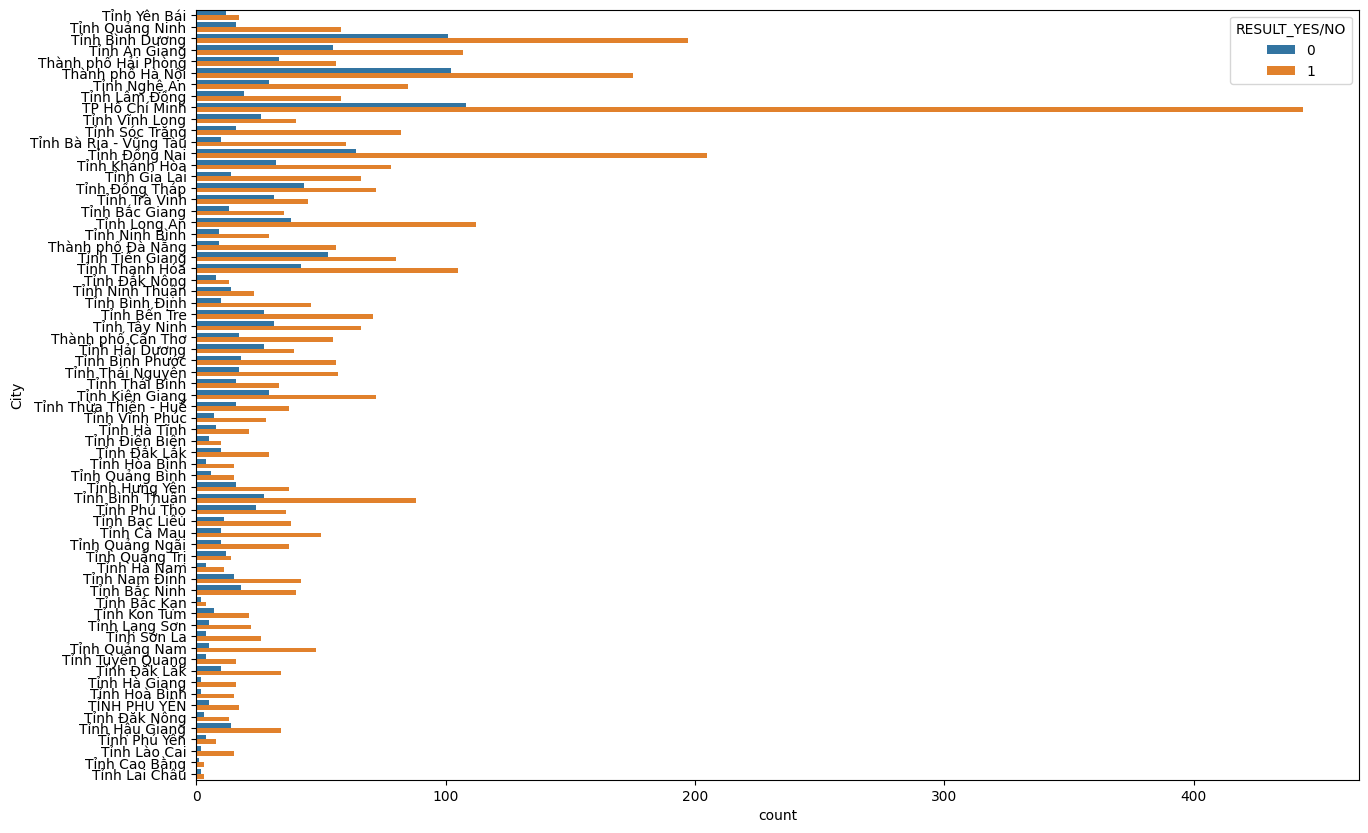

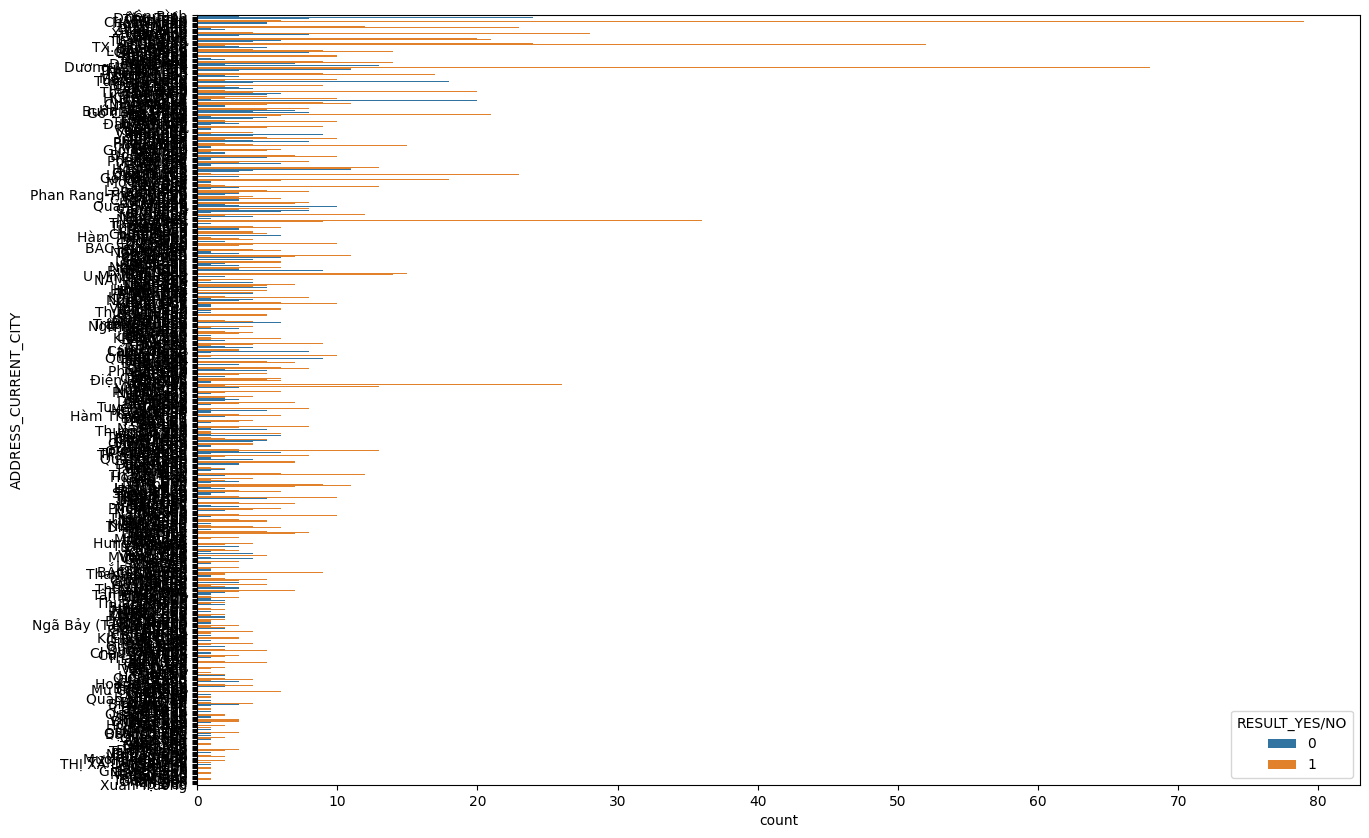

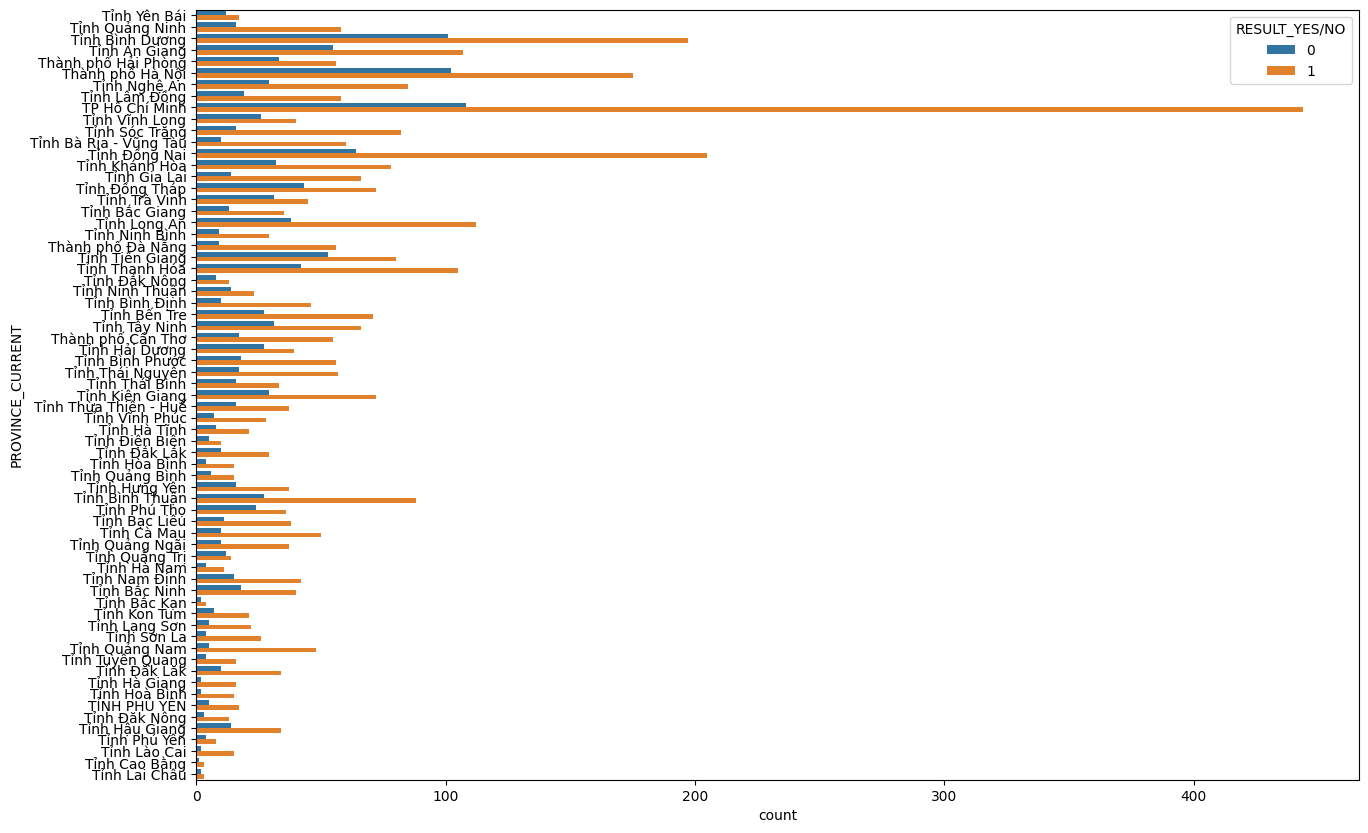

In [172]:

for var in categorical_vars:
    plt.figure(figsize=(15,10))
    if var != 'RESULT_YES/NO':
        sns.countplot(y=var, hue='RESULT_YES/NO', data=data)
        plt.show()

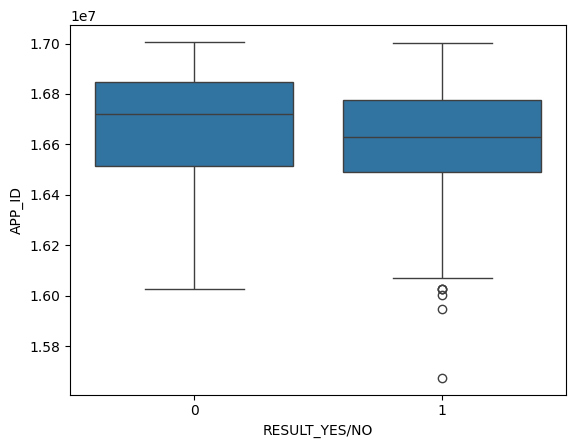

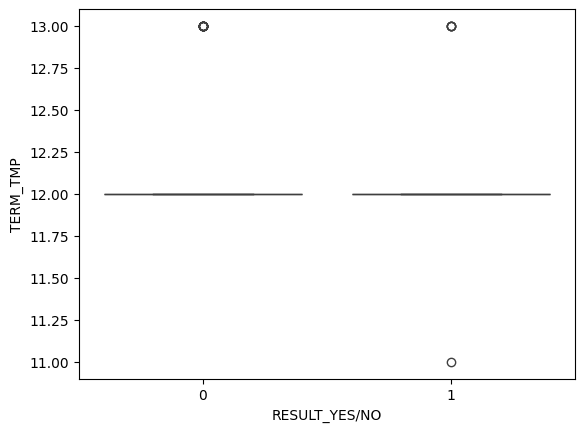

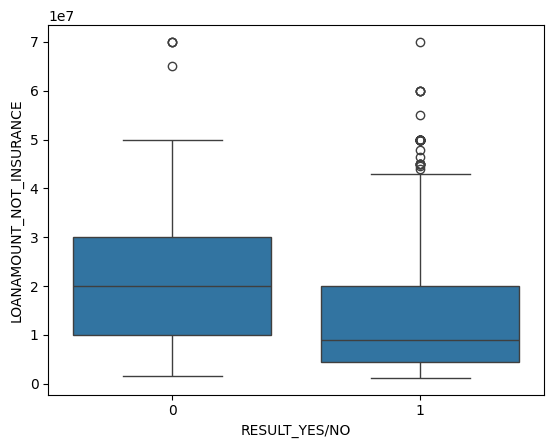

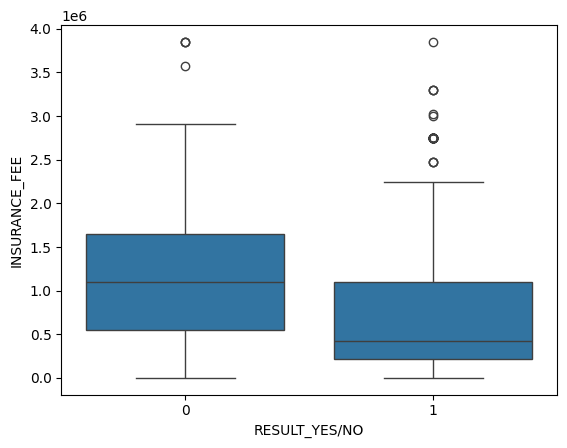

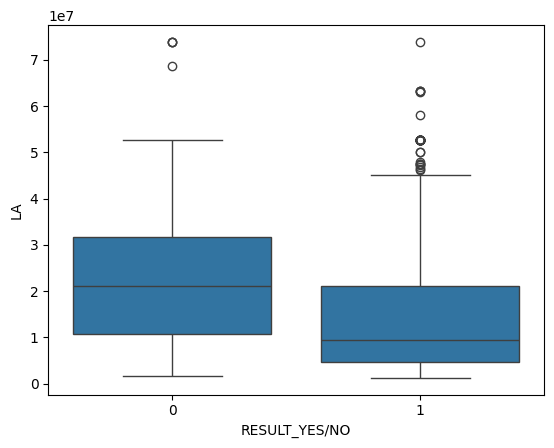

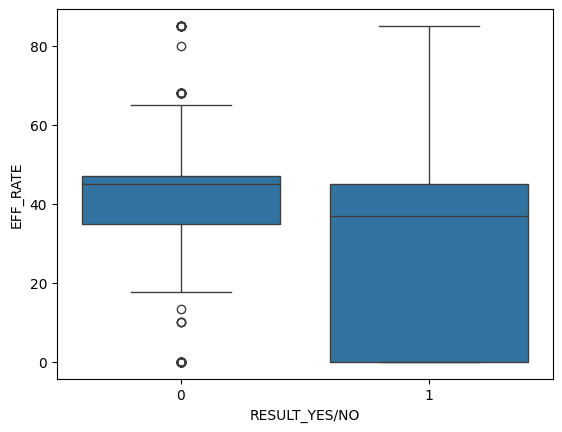

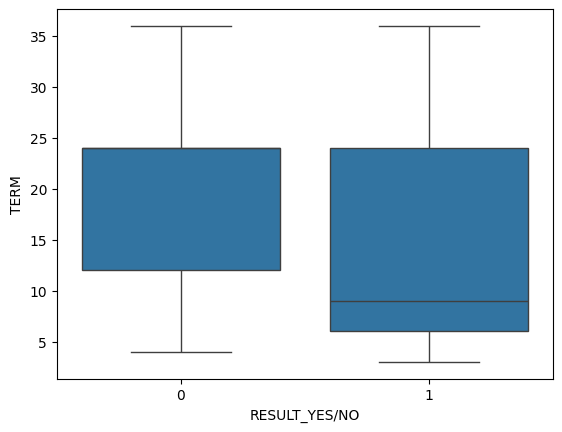

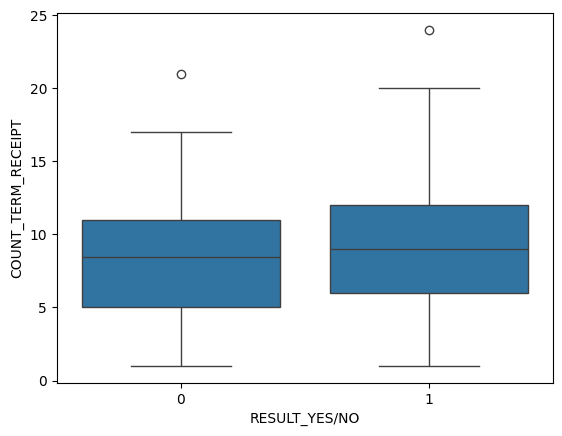

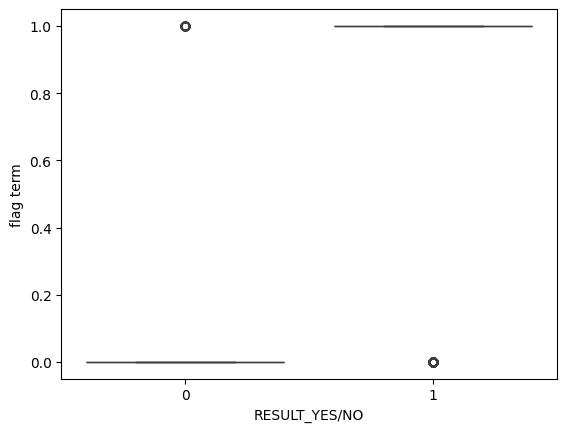

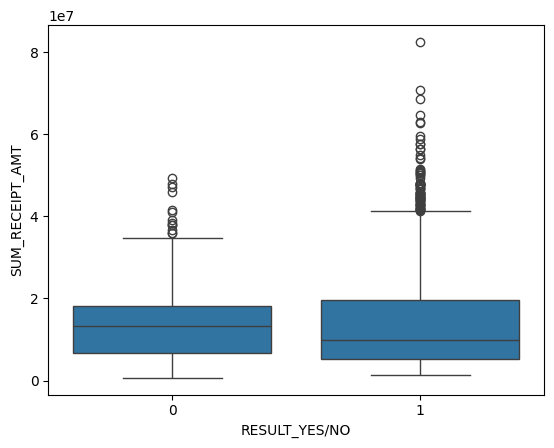

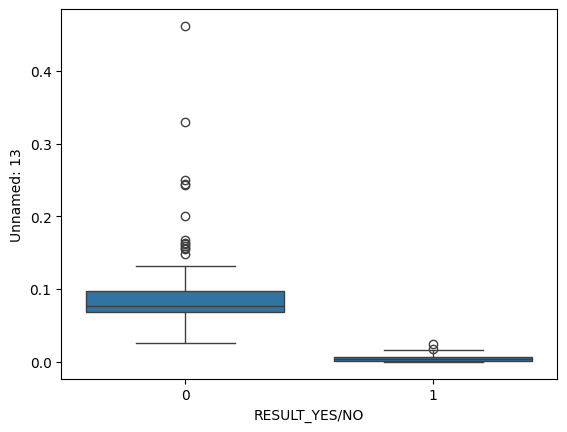

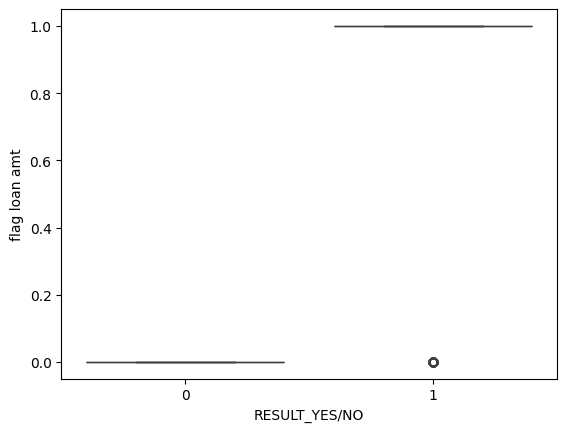

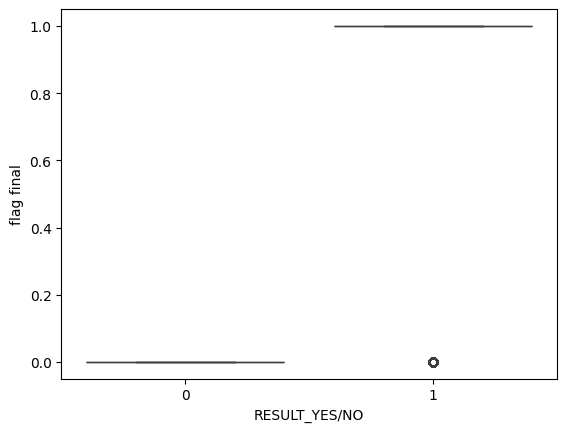

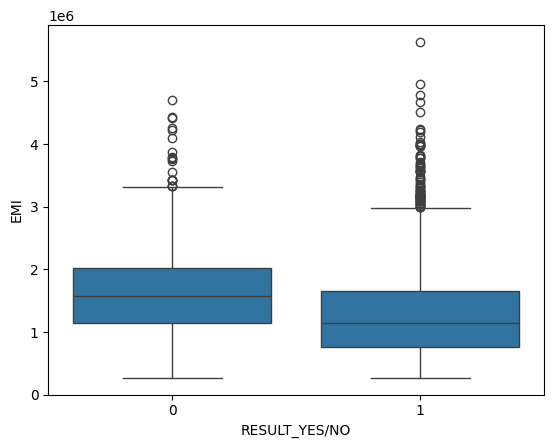

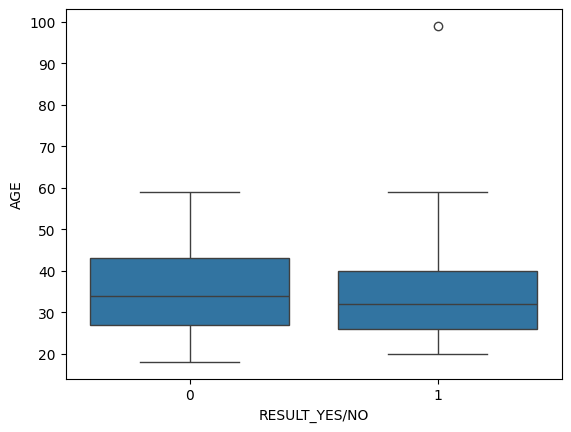

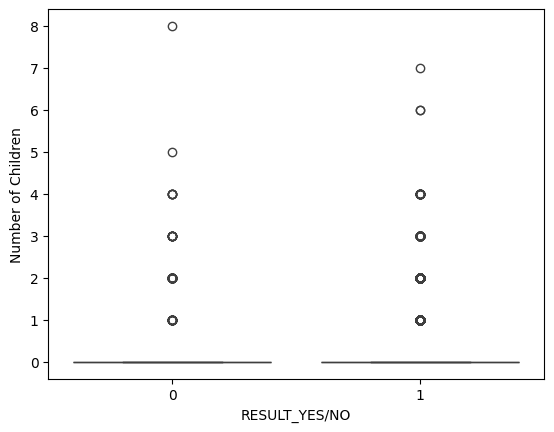

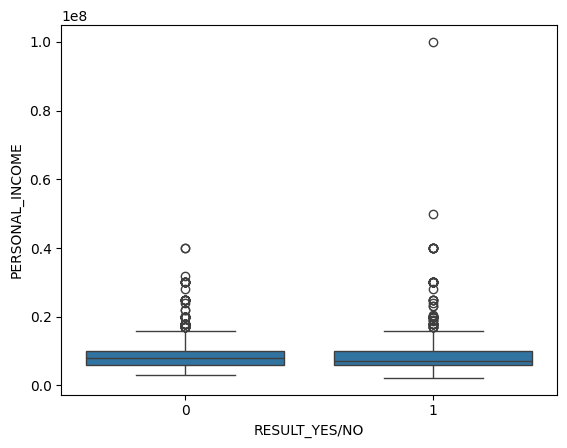

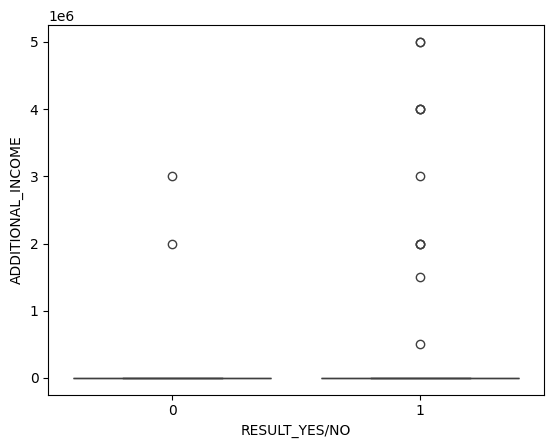

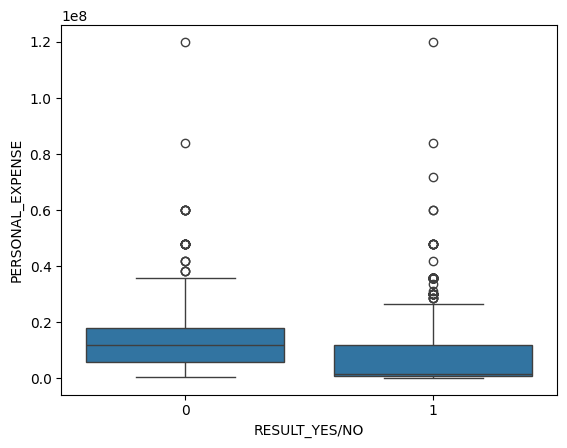

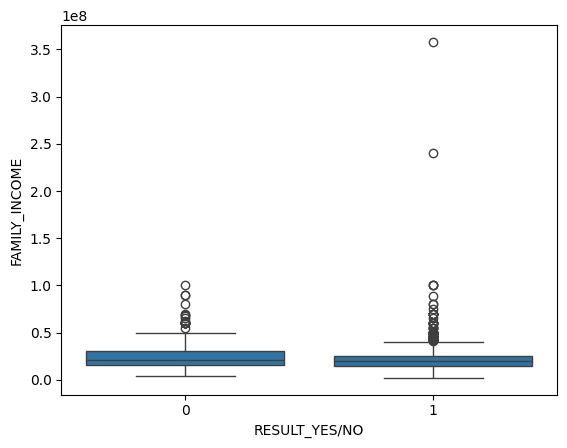

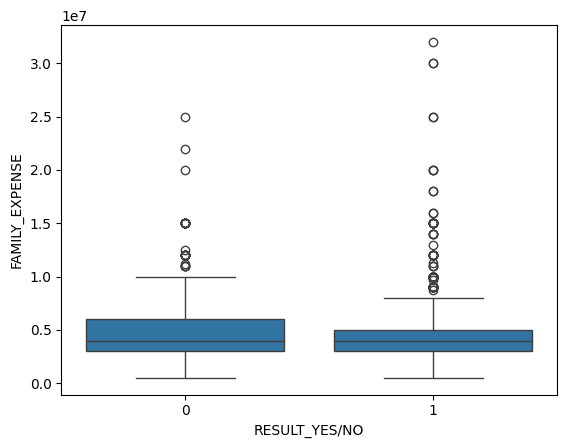

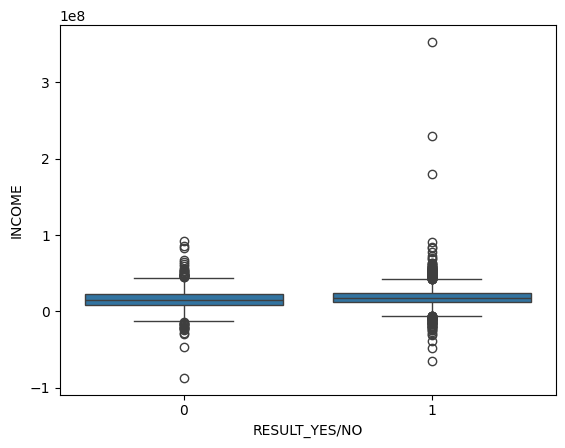

In [173]:
for var in numerical_vars:
    sns.boxplot(x='RESULT_YES/NO', y=var, data=data)
    plt.show()


In [373]:
data_train = data.copy()
data_train.drop(['RESULT_YES/NO'], axis=1, inplace=True)

In [374]:
epsilon = 1e-6
data_train['ID'] = data_train['EMI'] / (data_train['INCOME'] + epsilon)

In [375]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer


numerical_vars = data_train.select_dtypes(include=[np.number]).columns.to_list()
categorical_vars = data_train.select_dtypes(include=['object', 'category']).columns.to_list()

label_encoders = {}
for var in categorical_vars:
    if data_train[var].dtype == 'object' or data_train[var].dtype.name == 'category':
        le = LabelEncoder()
        data_train[var] = le.fit_transform(data_train[var].astype(str))
        label_encoders[var] = le


scaler = StandardScaler()
scaled_features = scaler.fit_transform(data_train[numerical_vars])
yeojohnTr = PowerTransformer(standardize=True)
yeojohn_features = yeojohnTr.fit_transform(data_train[numerical_vars])
# for i, var in enumerate(numerical_vars):
#     data_train[var] = scaled_features[:, i]

for i, var in enumerate(numerical_vars):
    data_train[var] = yeojohn_features[:, i]

In [377]:
data_train

,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,...,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,MARITAL_STATUS,EDUCATION,City,ADDRESS_CURRENT_CITY,PROVINCE_CURRENT,INCOME,ID
0,-0.771359,2017-10-10,2018-10-26,-1.387779e-17,134,0.503397,0.531531,0.508110,0.414934,1.038548,...,0.689453,0.003118,0.428797,3,3,59,571,59,-0.233023,0.012852
1,-0.815512,2017-10-10,2018-10-26,-1.387779e-17,151,-0.187217,-0.024735,-0.184085,0.393533,-0.077600,...,0.486273,-0.656429,-0.046257,2,3,45,604,45,-0.617384,0.037122
2,1.447177,2017-10-28,2018-10-26,-8.604228e-15,128,0.918385,0.898179,0.924120,0.500208,1.038548,...,0.845298,-2.975546,-2.566427,4,5,8,518,8,-1.496403,-0.759762
3,-1.485048,2017-10-04,2018-10-26,-1.387779e-17,151,1.158218,1.121343,1.164566,0.393533,1.038548,...,1.124608,0.003118,0.833004,2,5,6,353,6,-0.865769,0.172332
4,0.309810,2017-10-18,2018-10-26,-1.387779e-17,151,0.634145,0.644399,0.639175,0.393533,0.570200,...,0.845298,0.003118,1.186453,4,3,3,546,3,-0.715270,0.093138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.880444,2017-10-24,2018-10-26,-1.387779e-17,51,-0.808160,-0.339005,-0.795680,-1.796743,-1.134750,...,-0.979201,0.955180,-0.046257,2,3,2,274,2,1.171540,-0.027010
4996,-0.108129,2017-10-12,2018-10-26,-1.387779e-17,102,-0.670181,-0.442192,-0.673031,0.836411,-0.077600,...,-0.979201,-0.371083,0.428797,4,2,56,74,56,-0.036908,-0.016900
4997,1.624768,2017-10-30,2018-10-26,-1.387779e-17,67,-0.944675,-0.435806,-0.932686,-1.796743,-1.134750,...,-1.524568,0.003118,-1.393598,2,3,16,11,16,0.529263,-0.022960
4998,-1.217227,2017-10-03,2018-10-26,-1.387779e-17,4,-1.564252,-0.987867,-1.568073,1.247100,-1.134750,...,-0.450143,-0.656429,0.428797,2,1,12,139,12,-0.263185,-0.020926


In [378]:
attributes = []

data_no_outliers = data_train.copy()

for attribute in attributes:
    Q1 = data_train[attribute].quantile(0.25)
    Q3 = data_train[attribute].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data_no_outliers = data_no_outliers[(data_no_outliers[attribute] >= lower_bound) & (data_no_outliers[attribute] <= upper_bound)]


In [379]:
data_no_outliers.shape

(5000, 32)

In [384]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score

_data_train = data_no_outliers

columns = _data_train.columns.to_list()
columns_train = [
    'EFF_RATE', 
    'PRODUCT_NAME', 
    'LOANAMOUNT_NOT_INSURANCE', 
    'INSURANCE_FEE', 
    'GENDER', 
    'SUM_RECEIPT_AMT', 
    'INCOME', 
    'COUNT_TERM_RECEIPT', 
    'City', 
    'ADDRESS_CURRENT_CITY', 
    'EDUCATION', 
    'AGE',
]


drop_columns = list(set(columns).symmetric_difference(set(columns_train)))

X = _data_train.drop(columns=drop_columns) 
y_train = data['RESULT_YES/NO']
X_train = X#[y_train == 1]

X_test = data_train.drop(columns=drop_columns) 
y = data['RESULT_YES/NO']

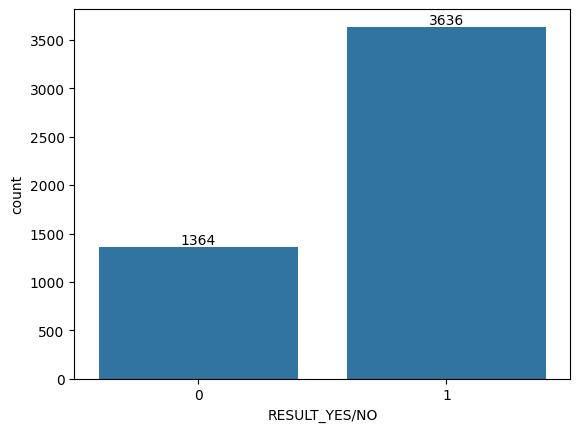

In [385]:
ax = sns.barplot(x=y_train.value_counts().index, y=y_train.value_counts(), )
for i in ax.containers:
    ax.bar_label(i, label_type='edge')

In [386]:
X_train.head(5)

,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,EFF_RATE,COUNT_TERM_RECEIPT,SUM_RECEIPT_AMT,GENDER,AGE,EDUCATION,City,ADDRESS_CURRENT_CITY,INCOME
0,134,0.503397,0.531531,0.414934,1.069069,0.431956,0,-0.303127,3,59,571,-0.233023
1,151,-0.187217,-0.024735,0.393533,1.384508,0.312975,0,-0.965061,3,45,604,-0.617384
2,128,0.918385,0.898179,0.500208,0.756441,0.789091,1,-1.617272,5,8,518,-1.496403
3,151,1.158218,1.121343,0.393533,0.446833,0.769369,0,-0.424641,5,6,353,-0.865769
4,151,0.634145,0.644399,0.393533,1.069069,0.838398,1,-1.274650,3,3,546,-0.715270


In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split


In [ ]:
X_train, y_train, X_test, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4500, 12), (500, 12), (4500,), (500,))

In [404]:
kmeans = KMeans(n_clusters=2, random_state=0).fit(X_train)
y_pred = kmeans.predict(X_test)

print(f'F1 Score: {f1_score(y_test, y_pred)}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [396]:
print(classification_report(y_train.astype('int32'), kmeans.predict(X_train)))

              precision    recall  f1-score   support

           0       0.28      0.54      0.37      1364
           1       0.73      0.48      0.58      3636

    accuracy                           0.49      5000
   macro avg       0.51      0.51      0.47      5000
weighted avg       0.61      0.49      0.52      5000



In [285]:
oc_svm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.03)  
oc_svm.fit(X_train)
decision_scores = oc_svm.decision_function(X_test)

Optimal threshold: -0.0004879093769220577


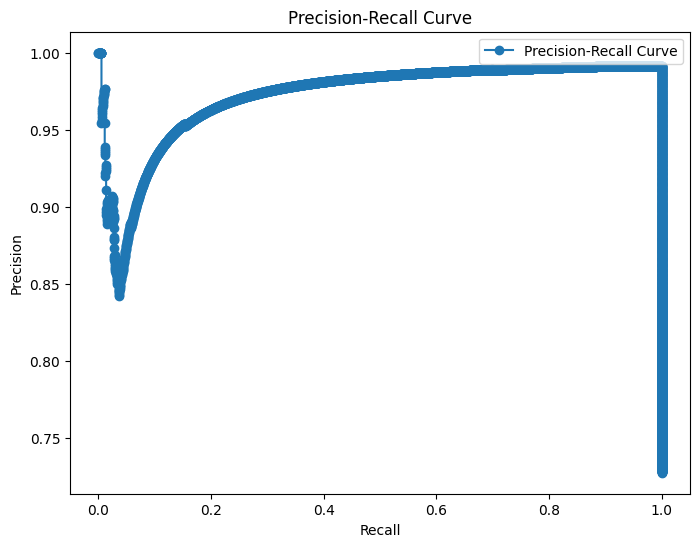

In [286]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y, decision_scores)
f1_scores = 2 * (precision * recall) / (precision + recall)
optimal_idx = np.argmax(f1_scores)

optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='o', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


In [287]:
y_pred_new = (decision_scores >= optimal_threshold).astype(int)
print(classification_report(y, y_pred_new))
average_precision = average_precision_score(y, y_pred_new)
print(f"Average Precision: {average_precision}")

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1364
           1       0.99      1.00      1.00      3636

    accuracy                           0.99      5000
   macro avg       1.00      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000

Average Precision: 0.9912758996728462
